In [1]:
import sys, os

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
print("Added to sys.path:/", repo_root)
from fixedincomelib import *

print("Fixed Income Library is loaded.")

Added to sys.path:/ /Users/kishore/Documents/NYU_FRE/Mkt To Models/FRE-GT-9743-Assignment-8
Fixed Income Library is loaded.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict
from scipy.stats import norm, qmc
from scipy.interpolate import PchipInterpolator

np.random.seed(42)

# 1. SABR Conversion

The SABR model is a stochastic volatility model developed by Hagan et al. The dynamics of the forward rate \(F(t)\) are:

$
dF(t)=\sigma(t)F^\beta(t)dW_1(t)
$

$
d\sigma(t)=\nu\sigma(t)dW_2(t)
$

$
dW_1 dW_2 = \rho dt
$

with initial conditions:

$
F(0)=F_0
$

$
\sigma(0)=\alpha
$

---

Using asymptotic expansion techniques, the equivalent Black volatility can be written as:

$
\sigma_{LN}^{B} =
\frac{\alpha}{(FK)^{(1-\beta)/2}}
\frac{z}{x(z)}
\omega_1
\left(1+\omega_2 T + \cdots \right)
$

---

### Definitions

$
z =
\frac{\nu}{\alpha}
(FK)^{(1-\beta)/2}
\log(F/K)
$

$
x(z) =
\log\left(
\frac{\sqrt{1-2\rho z+z^2}+z-\rho}{1-\rho}
\right)
$

$
\omega_1 =
1+
\frac{(1-\beta)^2}{24}\log^2(F/K)
+
\frac{(1-\beta)^4}{1920}\log^4(F/K)
+\cdots
$

$
\omega_2 =
\frac{(1-\beta)^2}{24}
\frac{\alpha^2}{(FK)^{1-\beta}}
+
\frac{1}{4}
\frac{\alpha\beta\rho\nu}{(FK)^{(1-\beta)/2}}
+
\frac{2-3\rho^2}{24}\nu^2
$

---

## Hagan's formula expansion around ATM

Notice that:

$
\frac{z}{x}=
\frac{z}
{\log\left(
\frac{\sqrt{1-2\rho z+z^2}+z-\rho}{1-\rho}
\right)}
$

This expression becomes indeterminate at \(z=0\), which corresponds to:

$
K=F
$

For small $z$, we use a Taylor expansion:

$
\frac{z}{x}
\approx 1
-\frac{1}{2}\rho z +
\left(
-\frac{1}{4}\rho^2+\frac{1}{6}
\right)z^2 -
\left(
\frac{1}{4}\rho^2-\frac{5}{24}
\right)\rho z^3+
\left(
-\frac{5}{16}\rho^4
+\frac{1}{3}\rho^2
-\frac{17}{360}
\right)z^4-
\left(
\frac{7}{16}\rho^4
-\frac{55}{96}\rho^2
+\frac{37}{240}
\right)\rho z^5
$

This expansion is typically sufficient when:

$
|z|<0.01
$

---

When the strike is very close to zero or very large, the density derived from the equivalent Black volatility may become negative or unstable. This motivates corrections to the wings of the Hagan expansion.

According to the readings above, please complete the functions referenced in `sabr.py`.

You may use the API provided above to implement both the volatility and risk functions. After that, run the code blocks below.

In [3]:
# utilities
def display_res(input_dict: Dict[SimpleMetrics, float]):
    display({k.to_string(): v for k, v in input_dict.items()})

In [4]:
### hagan's classic formula
alpha = 0.11
beta = 0.6
nu = 0.5
rho = 0.5
shift = 0.04
forward = 0.04
strike = 0.042
tte = 0.5

res_imp_log_normal_vol = qfEuropeanOptionSABRLogNormalSigma(
    forward, strike, tte, alpha, beta, rho, nu, shift, True
)
display_res(res_imp_log_normal_vol)

{'implied_log_normal_vol': np.float64(0.3075337080446443),
 'd_ln_sigma_d_alpha': np.float64(2.78364942646351),
 'd_ln_sigma_d_beta': np.float64(-0.7671990084031498),
 'd_ln_sigma_d_nu': np.float64(0.017789228437936306),
 'd_ln_sigma_d_rho': np.float64(0.0047994361581260095),
 'd_ln_sigma_d_forward': np.float64(-2.3980198155653976),
 'd_ln_sigma_d_strike': np.float64(0.8458659814736342),
 'd_ln_sigma_d_tte': np.float64(0.0075623430853099085),
 'd_ln_sigma_d_strike_strike': np.float64(15.446365846770282)}

In [5]:
# Section 1.1/1.2 — solver for sigma_ln_atm -> alpha and its sensitivities
F, T, beta, rho, nu, shift = 0.04, 0.5, 0.6, 0.5, 0.5, 0.04

# produce a reference atm lognormal vol from a known alpha, then back out alpha
alpha_ref = 0.11
sigma_ln_atm = qfEuropeanOptionSABRLogNormalSigma(F, F, T, alpha_ref, beta, rho, nu, shift)[
    SimpleMetrics.IMPLIED_LOG_NORMAL_VOL
]
print(f"reference sigma_ln_atm = {sigma_ln_atm:.8f}")

res_alpha = qfEuropeanOptionSABRAlphaFromATMLogNormalSigma(
    F, T, sigma_ln_atm, beta, rho, nu, shift, calc_risk=True
)
print("\nalpha and sensitivities (lognormal-atm -> alpha):")
display_res(res_alpha)
print(f"round-trip error |alpha - alpha_ref| = {abs(res_alpha[SabrMetrics.ALPHA]-alpha_ref):.2e}")

# finite-difference check for d alpha / d sigma_ln_atm
eps = 1e-6
up = qfEuropeanOptionSABRAlphaFromATMLogNormalSigma(F, T, sigma_ln_atm+eps, beta, rho, nu, shift)[SabrMetrics.ALPHA]
dn = qfEuropeanOptionSABRAlphaFromATMLogNormalSigma(F, T, sigma_ln_atm-eps, beta, rho, nu, shift)[SabrMetrics.ALPHA]
print(f"\nFD d_alpha/d_ln_sigma_atm = {(up-dn)/(2*eps):.8f}")
print(f"analytic                  = {res_alpha[SabrMetrics.D_ALPHA_D_LN_SIGMA_ATM]:.8f}")

reference sigma_ln_atm = 0.30587414

alpha and sensitivities (lognormal-atm -> alpha):


{'alpha': np.float64(0.11000000000000074),
 'd_alpha_d_ln_sigma_atm': np.float64(0.35741067861903947),
 'd_alpha_d_forward': np.float64(0.5500000000000037),
 'd_alpha_d_tte': np.float64(-0.0026948662467208497),
 'd_alpha_d_beta': np.float64(0.2769750258389835),
 'd_alpha_d_nu': np.float64(-0.00403509684808963),
 'd_alpha_d_rho': np.float64(0.00046387186249221494)}

round-trip error |alpha - alpha_ref| = 7.36e-16

FD d_alpha/d_ln_sigma_atm = 0.35741068
analytic                  = 0.35741068


In [6]:
# Section 1.3 — conversion from normal ATM vol to alpha (+ sensitivities via chain rule)
sigma_n_atm = qfEuropeanOptionSABRATMNormalSigmaFromAlpha(F, T, alpha_ref, beta, rho, nu, shift)[
    SimpleMetrics.IMPLIED_NORMAL_VOL
]
print(f"reference sigma_n_atm = {sigma_n_atm:.8f}")

res_alpha_n = qfEuropeanOptionSABRAlphaFromATMNormalSigma(
    F, T, sigma_n_atm, beta, rho, nu, shift, calc_risk=True
)
print("\nalpha and sensitivities (normal-atm -> alpha):")
display_res(res_alpha_n)
print(f"round-trip error |alpha - alpha_ref| = {abs(res_alpha_n[SabrMetrics.ALPHA]-alpha_ref):.2e}")

# FD check d_alpha / d_sigma_n_atm
eps = 1e-7
up = qfEuropeanOptionSABRAlphaFromATMNormalSigma(F, T, sigma_n_atm+eps, beta, rho, nu, shift)[SabrMetrics.ALPHA]
dn = qfEuropeanOptionSABRAlphaFromATMNormalSigma(F, T, sigma_n_atm-eps, beta, rho, nu, shift)[SabrMetrics.ALPHA]
print(f"\nFD d_alpha/d_n_sigma_atm = {(up-dn)/(2*eps):.8f}")
print(f"analytic                 = {res_alpha_n[SabrMetrics.D_ALPHA_D_NORMAL_SIGMA_ATM]:.8f}")

# Section 1.4 — European call with SABR under normal-sigma parameterization
K = 0.042
res_pv_n = qfEuropeanOptionSABRNormal(F, K, T, "call", sigma_n_atm, beta, rho, nu, shift, True)
print("\nEuropean call (normal-sigma SABR):")
display_res(res_pv_n)

# sanity: match alpha-parameterized pricer for the same effective alpha
pv_ref = qfEuropeanOptionSABR(F, K, T, "call", alpha_ref, beta, rho, nu, shift, False)[SimpleMetrics.PV]
print(f"PV (alpha-param)  = {pv_ref:.10f}")
print(f"PV (normal-param) = {res_pv_n[SimpleMetrics.PV]:.10f}")
print(f"abs error         = {abs(pv_ref - res_pv_n[SimpleMetrics.PV]):.2e}")

reference sigma_n_atm = 0.02442232

alpha and sensitivities (normal-atm -> alpha):


{'alpha': np.float64(0.10999999758301315),
 'd_alpha_d_normal_sigma_atm': np.float64(4.493834215547905),
 'd_alpha_d_forward': np.float64(-0.8218731355180133),
 'd_alpha_d_tte': np.float64(-0.002267693658225973),
 'd_alpha_d_beta': np.float64(0.27697501976805583),
 'd_alpha_d_rho': np.float64(0.00046387187930915476),
 'd_alpha_d_nu': np.float64(-0.004035096733695001)}

round-trip error |alpha - alpha_ref| = 2.42e-09

FD d_alpha/d_n_sigma_atm = 4.49383352
analytic                 = 4.49383422

European call (normal-sigma SABR):


{'pv': np.float64(0.006058209088784759),
 'delta': np.float64(0.39233016038212076),
 'gamma': np.float64(22.783559761041516),
 'theta': np.float64(-0.006968418196145278),
 'tte_risk': np.float64(0.006940211782467083),
 'strike_risk': np.float64(-0.3929589704297971),
 'dbeta': np.float64(8.580915424137234e-05),
 'drho': np.float64(0.0001374506200191392),
 'dnu': np.float64(0.0001479724217056673),
 'strike_risk_2': np.float64(22.154701684318212),
 'dnormalsigma': np.float64(0.28230046515184776)}

PV (alpha-param)  = 0.0060582092
PV (normal-param) = 0.0060582091
abs error         = 1.52e-10


# 2. Detection of Negative Density

The parameters set is:

In [7]:
# lower wing parameters
alpha = 0.0512
beta = 0.5
nu = 0.322
rho = -9.5/100
shift = 0.0
forward = 3.54/100
tte = 10

Density-negative region: K in [1.0e-04, 0.005783]
Arb-free lower-wing cutoff K* = 0.005783


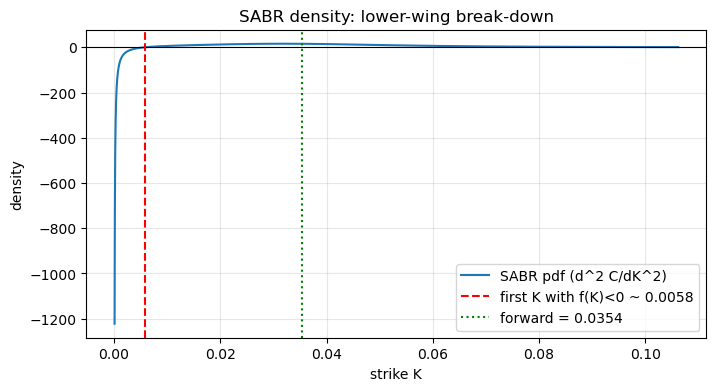

In [8]:
# Section 2 — detect strikes where SABR density turns negative (lower wing)
#
# Density via Breeden-Litzenberger:  f(K) = d^2 Call / dK^2
# `european_option_alpha(..., calc_risk=True)` already computes this by bump-reval
# and returns it under SimpleMetrics.STRIKE_RISK_2.

def sabr_pdf(Ks, alpha, beta, rho, nu, shift, forward, tte):
    out = np.empty_like(Ks, dtype=float)
    for i, K in enumerate(Ks):
        res = qfEuropeanOptionSABR(
            forward, float(K), tte, "call", alpha, beta, rho, nu, shift, True
        )
        out[i] = res[SimpleMetrics.STRIKE_RISK_2]
    return out


# lower-wing strike grid (starts well above 0 to keep bump-revals valid)
K_grid = np.concatenate([
    np.geomspace(1e-4, 1e-2, 120),
    np.linspace(1.01e-2, forward * 3.0, 280),
])
pdf = sabr_pdf(K_grid, alpha, beta, rho, nu, shift, forward, tte)

# Goal: find the lowest strike K* s.t. pdf(K) >= 0 for all K >= K*  (the lower-wing cutoff)
neg_mask = pdf < 0
if not neg_mask.any():
    K_star = None
    print("No negative density detected on this grid.")
else:
    # find the last index where density is negative
    last_neg_idx = np.where(neg_mask)[0][-1]
    lo = K_grid[last_neg_idx]
    hi = K_grid[last_neg_idx + 1] if last_neg_idx + 1 < len(K_grid) else K_grid[-1]
    # bisection in [lo, hi]
    for _ in range(80):
        mid = 0.5 * (lo + hi)
        pdf_mid = sabr_pdf(np.array([mid]), alpha, beta, rho, nu, shift, forward, tte)[0]
        if pdf_mid < 0:
            lo = mid
        else:
            hi = mid
    K_star = hi
    print(f"Density-negative region: K in [{K_grid[0]:.1e}, {K_star:.6f}]")
    print(f"Arb-free lower-wing cutoff K* = {K_star:.6f}")

# visualize density and mark the transition
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(K_grid, pdf, label="SABR pdf (d^2 C/dK^2)")
ax.axhline(0.0, color="k", lw=0.8)
if K_star is not None:
    ax.axvline(K_star, color="r", ls="--", label=f"first K with f(K)<0 ~ {K_star:.4f}")
ax.axvline(forward, color="g", ls=":", label=f"forward = {forward:.4f}")
ax.set_xlabel("strike K"); ax.set_ylabel("density")
ax.set_title("SABR density: lower-wing break-down")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

# 3. SABR Simulation and Density

For bump-and-revaluation calculations, please use the functions provided in `european_options.py`.

If an analytical solution is preferred, the corresponding implementation can be found in `sabr.py`.

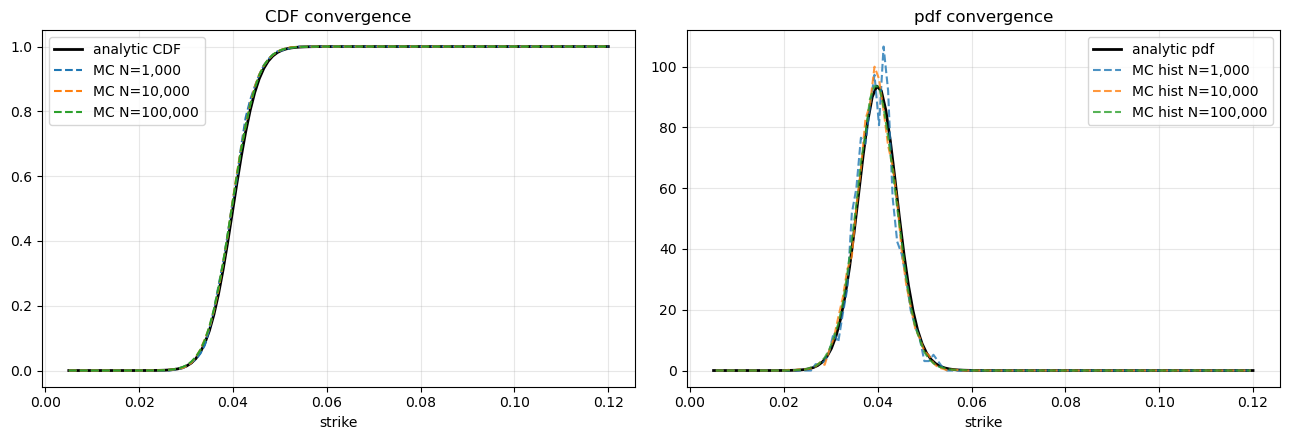

max|ecdf - cdf_analytic| as N grows:
  N =    1,000   ->   0.0442
  N =   10,000   ->   0.0308
  N =  100,000   ->   0.0257


In [9]:
# Section 3 — SABR simulation + density convergence
#
# SDE under shift s (shifted rate F' = F + s follows standard SABR):
#   dF' = sigma * F'^beta * dW1
#   d sigma = nu * sigma * dW2,   <dW1, dW2> = rho dt
# We use a log-Euler scheme for sigma (always positive) and absorbing-at-0 Euler for F'.

def simulate_sabr(
    forward, alpha, beta, rho, nu, tte, shift=0.0,
    n_paths=20_000, n_steps=50, seed=0,
):
    rng = np.random.default_rng(seed)
    dt = tte / n_steps
    sqrt_dt = np.sqrt(dt)
    F = np.full(n_paths, forward + shift, dtype=float)
    sig = np.full(n_paths, alpha, dtype=float)
    for _ in range(n_steps):
        z1 = rng.standard_normal(n_paths)
        z2 = rho * z1 + np.sqrt(1.0 - rho * rho) * rng.standard_normal(n_paths)
        # log-Euler on sigma (exact for GBM)
        sig *= np.exp(-0.5 * nu * nu * dt + nu * sqrt_dt * z2)
        # Euler on F' with absorbing barrier at 0
        F = F + sig * np.maximum(F, 0.0) ** beta * sqrt_dt * z1
        F = np.maximum(F, 0.0)
    return F - shift  # un-shifted terminal forward


def sabr_cdf_analytic(Ks, forward, alpha, beta, rho, nu, tte, shift=0.0):
    # CDF via Breeden-Litzenberger: F(K) = 1 + dCall/dK
    out = np.empty_like(Ks, dtype=float)
    for i, K in enumerate(Ks):
        res = qfEuropeanOptionSABR(
            forward, float(K), tte, "call", alpha, beta, rho, nu, shift, True
        )
        out[i] = 1.0 + res[SimpleMetrics.STRIKE_RISK]
    return out


def sabr_pdf_analytic(Ks, forward, alpha, beta, rho, nu, tte, shift=0.0):
    out = np.empty_like(Ks, dtype=float)
    for i, K in enumerate(Ks):
        res = qfEuropeanOptionSABR(
            forward, float(K), tte, "call", alpha, beta, rho, nu, shift, True
        )
        out[i] = res[SimpleMetrics.STRIKE_RISK_2]
    return out


# use a well-behaved parameter set (not the negative-density one)
forward_s = 0.04
alpha_s = 0.03
beta_s = 0.6
rho_s = -0.2
nu_s = 0.3
tte_s = 1.0
shift_s = 0.0

# analytic cdf/pdf
Ks = np.linspace(0.005, 0.12, 120)
cdf_ana = sabr_cdf_analytic(Ks, forward_s, alpha_s, beta_s, rho_s, nu_s, tte_s, shift_s)
pdf_ana = sabr_pdf_analytic(Ks, forward_s, alpha_s, beta_s, rho_s, nu_s, tte_s, shift_s)

# convergence: MC empirical CDF vs analytic
path_counts = [1_000, 10_000, 100_000]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(Ks, cdf_ana, "k", lw=2, label="analytic CDF")
axes[1].plot(Ks, pdf_ana, "k", lw=2, label="analytic pdf")
errs = []
for N in path_counts:
    samples = simulate_sabr(
        forward_s, alpha_s, beta_s, rho_s, nu_s, tte_s, shift_s,
        n_paths=N, n_steps=50, seed=N,
    )
    ecdf = np.searchsorted(np.sort(samples), Ks, side="right") / N
    axes[0].plot(Ks, ecdf, "--", label=f"MC N={N:,}")
    # kernel-ish: finite-diff of the ecdf
    hist, bin_edges = np.histogram(samples, bins=Ks)
    centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    axes[1].plot(centers, hist / (N * (bin_edges[1] - bin_edges[0])), "--",
                 alpha=0.8, label=f"MC hist N={N:,}")
    errs.append(np.max(np.abs(ecdf - cdf_ana)))

for ax in axes:
    ax.set_xlabel("strike"); ax.grid(alpha=0.3); ax.legend()
axes[0].set_title("CDF convergence"); axes[1].set_title("pdf convergence")
plt.tight_layout(); plt.show()

print("max|ecdf - cdf_analytic| as N grows:")
for N, e in zip(path_counts, errs):
    print(f"  N = {N:>8,d}   ->   {e:.4f}")

# 4. Quantile Map


In [ ]:

T_spread = 1.0
corr = 0.9

legs = [
    dict(S0=0.03, sigma_n=0.010, beta=0.5, nu=0.2,  rho=0.25, shift=0.0, name="S1"),
    dict(S0=0.05, sigma_n=0.012, beta=0.5, nu=0.15, rho=0.45, shift=0.0, name="S2"),
]

# atm-spread strike: K* = S1(0) - S2(0) = -0.02
K_payoff = legs[0]["S0"] - legs[1]["S0"]
print(f"Spread-option strike (atm-spread) K = {K_payoff:.4f}, T = {T_spread}")

# convert each leg's normal ATM vol to alpha 
for leg in legs:
    a = qfEuropeanOptionSABRAlphaFromATMNormalSigma(
        leg["S0"], T_spread, leg["sigma_n"], leg["beta"], leg["rho"], leg["nu"], leg["shift"]
    )[SabrMetrics.ALPHA]
    leg["alpha"] = a
    print(f"{leg['name']}: sigma_n={leg['sigma_n']:.4f} -> alpha={a:.6f}")

#  build CDF grid and quantile-map interpolators 
def build_quantile_map(leg, T, grid_min, grid_max, num_pts=201):
    S0 = leg["S0"]; shift = leg["shift"]
    alpha = leg["alpha"]; beta = leg["beta"]; rho = leg["rho"]; nu = leg["nu"]
    ks = np.linspace(grid_min, grid_max, num_pts)
    cdf = sabr_cdf_analytic(ks, S0, alpha, beta, rho, nu, T, shift)
    # enforce strict monotonicity (tiny numerical flat spots at the tails)
    cdf = np.clip(cdf, 1e-10, 1.0 - 1e-10)
    cdf = np.maximum.accumulate(cdf)
    y = norm.ppf(cdf)
    # drop non-strictly-increasing duplicates (keep first of each run)
    keep = np.concatenate([[True], np.diff(y) > 1e-12])
    y = y[keep]; ks = ks[keep]
    return PchipInterpolator(y, ks)

# grid covers ~ +- 6 atm-normal-sigmas around S0 (fine for these parameters)
for leg in legs:
    band = 6.0 * leg["sigma_n"] * np.sqrt(T_spread)
    lo = max(leg["S0"] - band, leg["shift"] + 1e-4)
    hi = leg["S0"] + band
    leg["I"] = build_quantile_map(leg, T_spread, lo, hi, num_pts=201)

#  Sobol sampling + correlation 
N = 2 ** 14  # 16384 quasi-random points
sobol = qmc.Sobol(d=2, scramble=True, seed=123)
s = sobol.random(N)
s = np.clip(s, 1e-12, 1.0 - 1e-12)
y_uncorr = norm.ppf(s)  # N x 2 independent normals

# Cholesky factor for 2x2 correlation
R = np.array([[1.0, corr], [corr, 1.0]])
B = np.linalg.cholesky(R)
y_corr = y_uncorr @ B.T

x1 = legs[0]["I"](y_corr[:, 0])
x2 = legs[1]["I"](y_corr[:, 1])
payoff = np.maximum(x1 - x2 - K_payoff, 0.0)
pv_qm = payoff.mean()
se_qm = payoff.std(ddof=1) / np.sqrt(N)
print(f"\nQuantile-map (Sobol) PV    = {pv_qm:.8f}   (std err ~ {se_qm:.2e})")

def simulate_two_correlated_sabr(legs, T, corr_fx, n_paths, n_steps, seed):
    """
    Simulate two correlated shifted-SABR forwards. Brownian vector
    Z = (W1_1, W2_1, W1_2, W2_2) with
        corr(W1_i, W2_i) = rho_i,
        corr(W1_1, W1_2) = corr_fx,
    other vol-spot crosses assumed 0.
    """
    rng = np.random.default_rng(seed)
    dt = T / n_steps; sdt = np.sqrt(dt)
    F = np.stack([np.full(n_paths, leg["S0"] + leg["shift"]) for leg in legs])
    sig = np.stack([np.full(n_paths, leg["alpha"]) for leg in legs])
    beta = np.array([leg["beta"] for leg in legs])
    nu = np.array([leg["nu"] for leg in legs])
    rho_i = np.array([leg["rho"] for leg in legs])
    # full 4x4 correlation, Cholesky.  With all cross-vol correlations set to
    # 0 the 4x4 matrix can be slightly non-PSD, so project to nearest PSD.
    C = np.eye(4)
    C[0, 1] = C[1, 0] = rho_i[0]
    C[2, 3] = C[3, 2] = rho_i[1]
    C[0, 2] = C[2, 0] = corr_fx
    eigvals, eigvecs = np.linalg.eigh(C)
    eigvals = np.maximum(eigvals, 1e-10)
    C = (eigvecs * eigvals) @ eigvecs.T
    d = np.sqrt(np.diag(C))
    C = C / np.outer(d, d)
    L = np.linalg.cholesky(C)
    for _ in range(n_steps):
        Z = rng.standard_normal((n_paths, 4)) @ L.T
        for k in range(2):
            Z1, Z2 = Z[:, 2 * k], Z[:, 2 * k + 1]
            sig[k] *= np.exp(-0.5 * nu[k] ** 2 * dt + nu[k] * sdt * Z2)
            F[k] = F[k] + sig[k] * np.maximum(F[k], 0.0) ** beta[k] * sdt * Z1
            F[k] = np.maximum(F[k], 0.0)
    return F[0] - legs[0]["shift"], F[1] - legs[1]["shift"]

try:
    x1_mc, x2_mc = simulate_two_correlated_sabr(legs, T_spread, corr, n_paths=50_000, n_steps=50, seed=7)
    payoff_mc = np.maximum(x1_mc - x2_mc - K_payoff, 0.0)
    pv_mc = payoff_mc.mean()
    se_mc = payoff_mc.std(ddof=1) / np.sqrt(len(payoff_mc))
    print(f"Brute-force 2D SABR MC PV = {pv_mc:.8f}   (std err ~ {se_mc:.2e})")
    print(f"|QM - MC| = {abs(pv_qm - pv_mc):.2e}  (combined ~ {1.96*np.sqrt(se_qm**2+se_mc**2):.2e} 95% CI)")
except Exception as e:
    print(f"MC validation failed: {e}")

Spread-option strike (atm-spread) K = -0.0200, T = 1.0
S1: sigma_n=0.0100 -> alpha=0.057644
S2: sigma_n=0.0120 -> alpha=0.053585

Quantile-map (Sobol) PV    = 0.00212197   (std err ~ 2.30e-05)
Brute-force 2D SABR MC PV = 0.00231727   (std err ~ 1.51e-05)
|QM - MC| = 1.95e-04  (combined ~ 5.38e-05 95% CI)
